# ELMo -- Contextual Embedding Evaluation

Loads the trained biLM (`models/elmo_M_best.pt`) and evaluates it the way `glove_eval.ipynb` evaluates GloVe,
adapted to one difference: **GloVe gives one vector per word, ELMo gives a different vector for the same word in
every sentence**, and each word has three layers (char-CNN token layer, LSTM layer 1, LSTM layer 2; layers 1-2 are
the concatenated forward|backward states, 512 dims). So the analyses that assumed a single vector are replaced:

0. Training curve (held-out perplexity per epoch, with and without `<unk>` targets).
1. **Context sensitivity per layer** -- how much does a word's vector change across sentences? Then the words
   that change the most, split into unsupervised clusters (t-SNE + printed sentences) to look for senses.
2. Nearest neighbors: static (context-averaged) neighbors per layer, and contextual neighbors of one occurrence.
3. Intrinsic word similarity / analogies (`evaluate_embeddings.py`) with a **static vector = average over corpus
   contexts**, per layer, next to GloVe.
4. K-Means clustering of sentiment words and entity-type words (same word lists as the GloVe notebook).
5. **Layer-wise POS probe** on NArabizi (the paper's "which layer encodes what" experiment), with a learned scalar
   mix, a randomly-initialised biLM control, GloVe as a static baseline, and a sample-efficiency curve.
6. Frozen-feature sentence classification: NArabizi sentiment and the 6-class dialect-ID set.
7. Learned scalar-mix layer weights per task, and a summary table.

How the layers are combined follows Peters et al. 2018 eq. 1: `gamma * sum_j softmax(s)_j * h_j`, with the biLM frozen
and only the mix + a linear layer trained. All probes standardize features with train statistics and pick the epoch
by dev accuracy; POS/sentence results are mean +- std over 3 seeds.

**Needs the GPU venv** (`ai-gpu` kernel) -- the biLM runs on CUDA -- and ~1 GB of free GPU memory, so run it when
`train.py` is not using the card (or use a finished checkpoint copy). Nothing here trains the biLM.

In [1]:
from __future__ import annotations

import json
import random
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, f1_score

import arabic_reshaper

ALGO_DIR = Path.cwd().resolve()
if ALGO_DIR.name != "elmo":
    ALGO_DIR = ALGO_DIR / "Embeddings" / "elmo"
ROOT = ALGO_DIR.parents[1]  # elmo -> Embeddings -> project root

sys.path.insert(0, str(ALGO_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Embeddings" / "intrinsic_eval" / "scripts"))

DATA_DIR = ALGO_DIR / "data"
MODELS_DIR = ALGO_DIR / "models"
GLOVE_DIR = ROOT / "Embeddings" / "glove"
CORPUS = ROOT / "Embeddings" / "word2vec_attention" / "data_bigcorpus" / "rows.jsonl"
EVAL_DATA_DIR = ROOT / "Embeddings" / "intrinsic_eval" / "data"

# Arabic-safe label rendering (same font order and reshaping convention as glove_eval.ipynb).
plt.rcParams["font.family"] = ["Tahoma", "Arial", "Segoe UI", "DejaVu Sans"]

ARABIC_RE = re.compile(r"[؀-ۿݐ-ݿࢠ-ࣿﭐ-﷿ﹰ-﻿]")
LATIN_RE = re.compile(r"[a-zA-ZÀ-ɏ]")


def render_label(text: str) -> str:
    """Reshape Arabic-script text into joined presentation-form glyphs for
    correct matplotlib display. Deliberately does NOT also apply
    bidi.get_display() -- this environment's matplotlib/font stack already
    lays reshaped RTL glyphs out correctly on its own (verified in
    word2vec_attention's notebook); get_display's extra reversal on top
    would produce a fully backwards word."""
    if ARABIC_RE.search(text):
        return arabic_reshaper.reshape(text)
    return text


def script_of(text: str) -> str:
    has_ar = bool(ARABIC_RE.search(text))
    has_lat = bool(LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"

TOKEN_RE = re.compile(r"\w+|[^\w\s]")   # must match prepare_data.py's tokenization
RESULTS: dict = {}                       # everything printed below also lands here -> models/elmo_eval_results.json

In [2]:
from elmo import ElmoEncoder, TOKEN_RE as _T, tokenize
assert _T.pattern == TOKEN_RE.pattern

# CHECKPOINT = MODELS_DIR / "elmo_M_last.pt"     # uncomment to override
try:
    CHECKPOINT
except NameError:
    CHECKPOINT = next((p for p in (MODELS_DIR / "elmo_M_best.pt", MODELS_DIR / "elmo_M_last.pt") if p.exists()), None)
assert CHECKPOINT is not None, "no checkpoint in models/ -- train first (see guide.md)"

enc = ElmoEncoder(CHECKPOINT, DATA_DIR)
# Same architecture, random weights: the control for "is it the training or just the architecture?"
enc_rand = ElmoEncoder(None, DATA_DIR, cfg=enc.model.cfg.to_dict(), seed=0)
D = enc.dim          # 512 = forward 256 | backward 256
D2 = D // 2

pc = enc.model.count_params()
print(f"checkpoint: {CHECKPOINT.name}   step {enc.info.get('step'):,}   epoch {enc.info.get('epoch')}")
print(f"{pc['total'] / 1e6:.1f}M parameters ({pc['non_softmax'] / 1e6:.1f}M outside the softmax); layer vectors are {D}-d")
if enc.info.get("epoch") is not None and enc.info["epoch"] < 4:
    print("WARNING: training has not reached epoch 4 -- these are intermediate results, not the final model.")
RESULTS["checkpoint"] = {"file": CHECKPOINT.name, "step": enc.info.get("step"), "epoch": enc.info.get("epoch")}

checkpoint: elmo_M_best.pt   step 98,586   epoch 3
28.7M parameters (23.5M outside the softmax); layer vectors are 512-d


## 0. Training curve

Held-out perplexity after each epoch (forward and backward direction), on 50K held-out comments that were removed
before the vocabulary was built. `<unk>` is ~19% of the target tokens (a 20K lowercased vocabulary on very
variable Arabizi spelling), and it is an easy class, so the perplexity *excluding* `<unk>` targets is the more
honest number. Neither is comparable to English biLM perplexities.

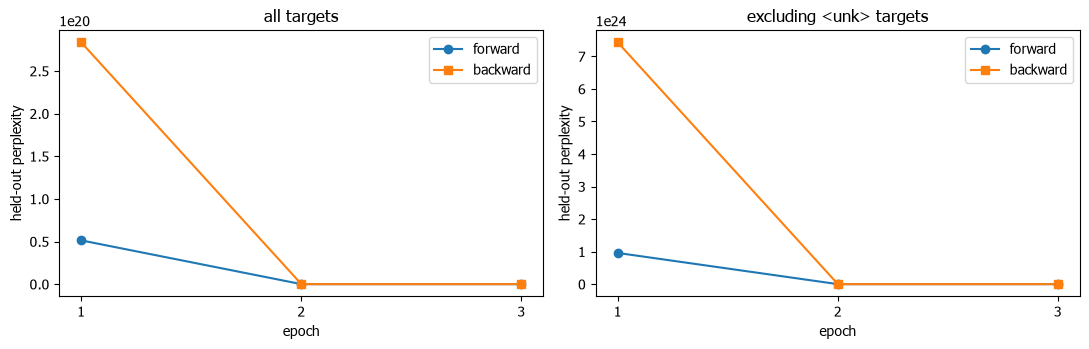

epoch 1: mean ppl 167420636325015486464.0  (excluding <unk> 4194659113468813476102144.0)
epoch 2: mean ppl 429.0  (excluding <unk> 1172.7)
epoch 3: mean ppl 100.3  (excluding <unk> 200.7)


In [3]:
hist = enc.info.get("history") or []
if hist:
    ep = [h["epoch"] for h in hist]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, suffix, title in ((axes[0], "", "all targets"), (axes[1], "_nounk", "excluding <unk> targets")):
        ax.plot(ep, [h[f"ppl_fwd{suffix}"] for h in hist], "o-", label="forward")
        ax.plot(ep, [h[f"ppl_bwd{suffix}"] for h in hist], "s-", label="backward")
        ax.set_xlabel("epoch"); ax.set_ylabel("held-out perplexity"); ax.set_title(title); ax.set_xticks(ep); ax.legend()
    plt.tight_layout(); plt.show()
    for h in hist:
        print(f"epoch {h['epoch']}: mean ppl {h['ppl_mean']:.1f}  (excluding <unk> {h['ppl_mean_nounk']:.1f})")
    RESULTS["perplexity_history"] = hist
else:
    print("no history stored in this checkpoint")

## Word lists and corpus contexts

A contextual model needs sentences. Words to embed are collected once here, then one pass over **random blocks of
the big corpus** (`rows.jsonl`, 300 random file offsets x 1,500 consecutive comments -- random offsets because the
file is ordered by video, so the head of the file would be a few channels) gathers up to N contexts (4-40 tokens)
per word. Words with no context in the sample are embedded alone, as a one-word sentence (counted below).
The corpus overlaps the biLM's training text; that is fine here because nothing in sections 1-4 scores the
language-model objective itself.

In [4]:
def load_curated_words() -> list[str]:
    words: set[str] = set()
    with (EVAL_DATA_DIR / "word_similarity.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                words.update((row["word1"], row["word2"]))
    with (EVAL_DATA_DIR / "analogy_pairs.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                for p in json.loads(line)["pairs"]:
                    words.update((p["word_a"], p["word_b"]))
    return sorted(words)


curated_words = load_curated_words()

vocab_out = json.loads((DATA_DIR / "vocab_out.json").read_text(encoding="utf-8"))   # lowercased, frequency-ordered
PLACEHOLDERS = {"url", "mention"}
freq_words = [w for w in vocab_out[4:] if script_of(w) in ("arabic", "latin", "mixed") and w not in PLACEHOLDERS]
POOL = freq_words[:3000]      # neighbor-search pool (section 2)
SENS = freq_words[:200]       # context-sensitivity study (section 1)

# Words that are likely to be ambiguous, looked at in section 1 next to the automatically found ones:
# dar (house / did), kan (was / if). Arabic spellings as escapes.
AMB_HAND = ["dar", "\u062f\u0627\u0631", "kan", "\u0643\u0627\u0646"]

demo_words = ["\u0628\u0632\u0627\u0641", "\u062e\u062f\u0645\u0629", "\u0648\u0627\u0634", "\u062d\u0628\u064a\u0628\u064a", "\u0645\u0644\u064a\u062d", "\u0648\u0644\u062f", "\u0628\u0646\u062a", "\u0632\u064a\u0646"]
arabizi_demo_words = ["bezzaf", "wallah", "khoya", "hbibi", "zin", "chkoun", "algerie"]
POSITIVE_WORDS = ["\u0645\u0644\u064a\u062d", "\u0632\u064a\u0646", "\u0641\u0631\u062d\u0627\u0646", "\u062d\u0644\u0648", "\u0639\u062c\u0628\u0646\u064a", "\u0631\u0627\u0626\u0639", "\u0645\u0628\u0631\u0648\u0643", "\u0628\u0646\u064a\u0646", "\u062c\u0645\u064a\u0644", "\u0648\u0627\u0639\u0631"]
NEGATIVE_WORDS = ["\u062e\u0627\u064a\u0628", "\u0642\u0628\u064a\u062d", "\u062d\u0632\u064a\u0646", "\u0632\u0639\u0641\u0627\u0646", "\u0645\u0634\u0643\u0644", "\u062a\u0639\u0628\u0627\u0646", "\u063a\u0644\u0637", "\u0635\u0639\u064a\u0628", "\u0645\u0642\u0631\u0641", "\u0636\u0639\u064a\u0641"]
PERSON_WORDS = ["\u0645\u062d\u0645\u062f", "\u0623\u062d\u0645\u062f", "\u064a\u0648\u0633\u0641", "\u0633\u0627\u0631\u0629", "\u0641\u0627\u0637\u0645\u0629", "\u062e\u062f\u064a\u062c\u0629", "\u0643\u0631\u064a\u0645", "\u064a\u0627\u0633\u064a\u0646"]
LOCATION_WORDS = ["\u0627\u0644\u062c\u0632\u0627\u0626\u0631", "\u0648\u0647\u0631\u0627\u0646", "\u0642\u0633\u0646\u0637\u064a\u0646\u0629", "\u0639\u0646\u0627\u0628\u0629", "\u062a\u0644\u0645\u0633\u0627\u0646", "\u0628\u062c\u0627\u064a\u0629", "\u0641\u0631\u0646\u0633\u0627", "\u0628\u0627\u0631\u064a\u0633"]
ORGANIZATION_WORDS = ["\u0627\u0644\u062d\u0643\u0648\u0645\u0629", "\u0627\u0644\u062c\u064a\u0634", "\u0627\u0644\u0634\u0631\u0637\u0629", "\u0627\u0644\u062c\u0627\u0645\u0639\u0629", "\u0627\u0644\u0648\u0632\u0627\u0631\u0629", "\u0627\u0644\u0628\u0646\u0643", "\u0627\u0644\u0634\u0631\u0643\u0629", "\u0627\u0644\u0645\u062f\u0631\u0633\u0629"]
TIME_DATE_WORDS = ["\u0627\u0644\u064a\u0648\u0645", "\u063a\u062f\u0648\u0629", "\u0627\u0644\u0628\u0627\u0631\u062d", "\u0627\u0644\u0635\u0628\u0627\u062d", "\u0627\u0644\u0644\u064a\u0644", "\u0627\u0644\u0623\u0633\u0628\u0648\u0639", "\u0627\u0644\u0634\u0647\u0631", "\u0627\u0644\u0633\u0646\u0629"]

TASKS = {
    "sentiment (k=2)": ({"positive": POSITIVE_WORDS, "negative": NEGATIVE_WORDS}, 2),
    "entity type (k=4)": ({"person": PERSON_WORDS, "location": LOCATION_WORDS,
                           "organization": ORGANIZATION_WORDS, "time_date": TIME_DATE_WORDS}, 4),
}

caps: dict[str, int] = {}
def want(words, n):
    for w in words:
        for t in TOKEN_RE.findall(w.lower()):
            caps[t] = max(caps.get(t, 0), n)

want(curated_words, 20); want(POOL, 10); want(SENS, 40); want(AMB_HAND, 150); want(demo_words + arabizi_demo_words, 20)
for groups, _ in TASKS.values():
    for ws in groups.values():
        want(ws, 20)
print(f"{len(curated_words)} curated words, {len(POOL)} pool words, {len(caps):,} distinct tokens to find contexts for")

463 curated words, 3000 pool words, 3,287 distinct tokens to find contexts for


In [5]:
def sample_rows(n_blocks=300, lines_per_block=1500, seed=0):
    size = CORPUS.stat().st_size
    rng = random.Random(seed)
    offsets = sorted(rng.randrange(0, size - 10_000_000) for _ in range(n_blocks))
    with CORPUS.open("rb") as f:
        for off in offsets:
            f.seek(off)
            f.readline()                       # drop the partial line
            for _ in range(lines_per_block):
                line = f.readline()
                if not line:
                    break
                yield json.loads(line)["text"]


CTX: dict[str, list] = {t: [] for t in caps}     # token -> [(tokens_of_sentence, position), ...]
t0, n_rows = time.time(), 0
for text in sample_rows():
    n_rows += 1
    toks = TOKEN_RE.findall(text)
    if not 4 <= len(toks) <= 40:
        continue
    seen = set()
    for i, tok in enumerate(toks):
        tl = tok.lower()
        if tl in caps and tl not in seen and len(CTX[tl]) < caps[tl]:
            CTX[tl].append((toks, i))
            seen.add(tl)

full = sum(len(CTX[t]) >= caps[t] for t in caps)
some = sum(0 < len(CTX[t]) < caps[t] for t in caps)
none = sum(len(CTX[t]) == 0 for t in caps)
print(f"scanned {n_rows:,} comments in {time.time() - t0:.0f}s: {full:,} tokens with full contexts, {some:,} partial, {none:,} with none (embedded alone)")

scanned 450,000 comments in 10s: 3,149 tokens with full contexts, 117 partial, 21 with none (embedded alone)


In [6]:
TOKVEC: dict[str, np.ndarray] = {}    # token -> (3, D) average over its contexts
NO_CTX: set[str] = set()


def prime(tokens, chunk_words=1000):
    todo = [t for t in dict.fromkeys(tokens) if t not in TOKVEC]
    for c in range(0, len(todo), chunk_words):
        part = todo[c:c + chunk_words]
        sents, pos, owner = [], [], []
        for k, t in enumerate(part):
            ctx = CTX.get(t) or []
            if not ctx:
                NO_CTX.add(t)
                ctx = [([t], 0)]
            for toks, i in ctx:
                sents.append(toks); pos.append(i); owner.append(k)
        V = enc.encode_positions(sents, pos)                                   # (N, 3, D)
        owner_t = torch.tensor(owner)
        sums = torch.zeros(len(part), 3, D).index_add_(0, owner_t, V)
        cnt = torch.bincount(owner_t, minlength=len(part)).clamp_min(1).view(-1, 1, 1)
        for t, v in zip(part, (sums / cnt).numpy()):
            TOKVEC[t] = v


def word_static(word: str):
    # Static (3, D) vector for a word or a multi-word phrase: mean over corpus contexts of each token.
    toks = TOKEN_RE.findall(word.lower())
    if not toks:
        return None
    prime(toks)
    return np.mean([TOKVEC[t] for t in toks], axis=0)


def ctx_vectors(word: str, n: int):
    # The individual contextual vectors of one word: (n, 3, D) and the (tokens, position) list they came from.
    ctx = CTX.get(word.lower(), [])[:n]
    if not ctx:
        return None, []
    return enc.encode_positions([c[0] for c in ctx], [c[1] for c in ctx]).numpy(), ctx


def show(tokens, i, width=14):
    lo = max(0, i - width)
    return " ".join(tokens[lo:i] + ["\u00ab" + tokens[i] + "\u00bb"] + tokens[i + 1:i + 1 + width])


t0 = time.time()
all_tokens = list(caps)
prime(all_tokens)
print(f"static vectors for {len(TOKVEC):,} tokens in {time.time() - t0:.0f}s ({len(NO_CTX):,} embedded without a corpus context)")

static vectors for 3,287 tokens in 18s (21 embedded without a corpus context)


## 1. Context sensitivity per layer

For each of the 200 most frequent words (up to 40 contexts each), the mean pairwise cosine between that word's
vectors in different sentences ("self-similarity"), per layer. Layer 0 (the char-CNN) sees only the word's
spelling, so it must be exactly 1.0 -- a built-in sanity check of the pipeline. The paper's finding is that
higher layers move more with context. The **baseline** is the cosine between random occurrences of *different*
words: recurrent-net states share a large common direction, so raw cosines are inflated, and what matters is
how far self-similarity sits above the baseline.

200 frequent words with >= 10 contexts
layer                 mean self-sim   baseline (different words)
layer 0 (char-CNN)            0.998                        0.365
layer 1                       0.922                        0.316
layer 2                       0.725                        0.105
29/200 words have >1 literal spelling among their sampled contexts, exactly why the raw layer-0 self-sim above is a bit below 1.0
layer 0 self-similarity WITHIN exact spelling (228 groups): mean 1.000000, min 0.999999


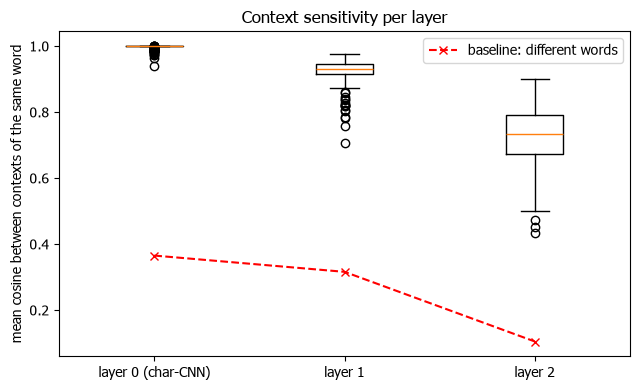

In [7]:
sens_vecs = {}
sens_ctx = {}
for w in SENS:
    V, ctx = ctx_vectors(w, 40)
    if V is not None and len(V) >= 10:
        sens_vecs[w] = V
        sens_ctx[w] = ctx


def mean_pairwise_cos(V):
    Vn = V / np.clip(np.linalg.norm(V, axis=1, keepdims=True), 1e-9, None)
    n = len(Vn)
    return float((Vn @ Vn.T).sum() - n) / (n * (n - 1))


self_sim = {l: [mean_pairwise_cos(V[:, l]) for V in sens_vecs.values()] for l in range(3)}

rng = np.random.default_rng(0)
allV = np.concatenate([V for V in sens_vecs.values()])
owner = np.concatenate([[k] * len(V) for k, V in enumerate(sens_vecs.values())])
a, b = rng.integers(0, len(allV), 50000), rng.integers(0, len(allV), 50000)
keep = owner[a] != owner[b]
baseline = []
for l in range(3):
    A, B = allV[a[keep], l], allV[b[keep], l]
    baseline.append(float(np.mean((A * B).sum(1) / np.clip(np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1), 1e-9, None))))

names = ["layer 0 (char-CNN)", "layer 1", "layer 2"]
print(f"{len(sens_vecs)} frequent words with >= 10 contexts")
print(f"{'layer':<20} {'mean self-sim':>14} {'baseline (different words)':>28}")
for l in range(3):
    print(f"{names[l]:<20} {np.mean(self_sim[l]):>14.3f} {baseline[l]:>28.3f}")

# The char-CNN is deliberately CASED (model.py: "cased input, lowercased output"), but `w` here is a
# case-folded vocabulary entry, so its contexts can mix different literal spellings ("wach"/"Wach"/"WACH")
# that get real (not noise) different layer-0 vectors -- correct model behaviour, not context leakage. The
# actual context-free claim is per EXACT spelling: split each word's contexts by the literal token string
# and check layer 0 is constant WITHIN each spelling group.
exact_sims, n_multi_spelling = [], 0
for w, ctx in sens_ctx.items():
    V = sens_vecs[w][:, 0]
    spellings = [toks[i] for toks, i in ctx]
    by_spelling = {}
    for k, s in enumerate(spellings):
        by_spelling.setdefault(s, []).append(k)
    if len(by_spelling) > 1:
        n_multi_spelling += 1
    for idxs in by_spelling.values():
        if len(idxs) >= 2:
            exact_sims.append(mean_pairwise_cos(V[idxs]))

print(f"{n_multi_spelling}/{len(sens_vecs)} words have >1 literal spelling among their sampled contexts, ", end="")
print("exactly why the raw layer-0 self-sim above is a bit below 1.0")
print(f"layer 0 self-similarity WITHIN exact spelling ({len(exact_sims)} groups): mean {np.mean(exact_sims):.6f}, min {np.min(exact_sims):.6f}")
assert abs(np.mean(exact_sims) - 1.0) < 1e-3, "layer 0 must be context-free for a fixed literal spelling"

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.boxplot([self_sim[l] for l in range(3)])  # tick_labels kwarg name changed across matplotlib versions -- set separately below
ax.plot(range(1, 4), baseline, "rx--", label="baseline: different words")
ax.set_xticks(range(1, 4)); ax.set_xticklabels(names)
ax.set_ylabel("mean cosine between contexts of the same word"); ax.legend(); ax.set_title("Context sensitivity per layer")
plt.tight_layout(); plt.show()
RESULTS["self_similarity"] = {"mean": [float(np.mean(self_sim[l])) for l in range(3)], "baseline": baseline,
                               "layer0_exact_spelling_self_sim": float(np.mean(exact_sims))}

### Words that change the most, and what their contexts look like

The three most context-dependent frequent words (lowest layer-2 self-similarity) plus the hand-picked `dar` / `kan`
(both have several distinct uses in Darija). Their layer-2 vectors are clustered with K-Means (k=2,
**unsupervised, no sense labels**) and plotted with t-SNE, and three sentences per cluster are printed with the word
marked `<<word>>`. These clusters are candidate senses, not gold senses -- read the sentences to judge whether the
split is a meaningful one (noun/verb, topic, register) or just noise. Words with fewer than 20 contexts are skipped.


=== الله  (layer-2 self-similarity 0.434) ===
 cluster 0:
    «الله» يبارك الدولفين تحول للبڨرة أياو نروحو للطبيب
    «الله» يفرحك خليتني نضحك 😂 .
    يا . روح «الله» يهديك يا خويا رادكس 😂 😂
 cluster 1:
    😂 😂 شفت التعليقات نتع الانستا واليوتيوب فرق كبير ما شاء «الله»
    الحمد «الله» اديت فوق الاعشرة11 . 55 😁 😁
    جربت بقرا ودلفين سبحان «الله» 😂 😂



=== من  (layer-2 self-similarity 0.453) ===
 cluster 0:
    انا بموت «من» التوتر 😂 💔
    😂 😂 بقره ودلفين «من» نيتك
    خاوتي ادعيولي طبيب قالي 3 أيام و تموت «من» التوتر 😂
 cluster 1:
    كملي ربي ينجحك متابعتك «من» وهران
    لولا . راكي . محروسه . «من» . كل . عين . لامه . ربي . يسطرك . بالتوفيق . ❤
    [ MENTION ] انا بموت فيكي ياقلبي ❤ بسس اقدر اشتريه ومن وين انا «من» الجزائر ام البواقي



=== أو  (layer-2 self-similarity 0.473) ===
 cluster 0:
    تقدريلها كيفاش لولا متقدرلهاش ❤ نحبك «أو» نعتمد عليك 😊 _ I LOVE YOU ❤ 💋
    أنا رحت «أو» شفت قناتها ❤ نهار كامل ندعيلها بالخير
    اليوم عشيا كامل «أو» انا شوف les vidéos ta3k أو درك نكمل الليل ؟ بزااف حاوزني رضا 🤣
 cluster 1:
    راهي كاينة بقرة «أو» دلفين
    اديني معاك راني نشوف ودفا «أو» بقرة
    انا كاتبه قصه لكن الوطن غير مساهم لنا نحن القراء «أو» بالأحرى جيل الغذ نتمنى يوقفو معانا حيت دزنا من تجارب بزاف وفهماتنا حوايج الي



=== dar  (layer-2 self-similarity 0.859) ===
 cluster 0:
    «Dar» essad ce nom en arab mais les lettres en français et la traduction de
    8000 «dar» da3ara a alger la capitale . 13 millions homosexuels algériens . Les algeriennes se
    «Dar» el hadith a été créé par les tlemceniens monsieur
 cluster 1:
    ana khdemt m3ahom o makhalsonich big scammers hta boss ta3hom «dar» big scam b milliars de dollars o 9ela3 rah motaba3 dowaliyan
    Lferha ✖ redx «dar» vd ✔ 😂 😂 chkn m3aya
    Black kitchen de5la f restoration f food industry Taybi ll client f «dar» te3k w twsleh ll dar Hadi fikra deyra 7ala f la chine



=== دار  (layer-2 self-similarity 0.636) ===
 cluster 0:
    راني نشوف في دنفيل مع بقرة يأنا «دار» عقلي يأنت درتني تحريشة
    يا رضا هادي لقلت دارت عمليات باش تولي تشبه لهم ماشي طفلة هذاك راجل «دار» عملية باش يولي يشبه لجيمين من فرقة بتس و اسمو اولي لندن لكن ارمي
    لوكان حكيت على أولي لندن لراح «دار» عملية باش يولي يشبه للجيمن من بتس 🤣
 cluster 1:
    رضا جاي يتبهلل علينا وقيلة . . . انا درك في «دار» جداتي غدوة يعطونا المعدلات دعولي بالرحمة
    عسي روحك ما تطلعيش من «دار» جدك حتى يسهل ربي
    ممكن من فضلك بعد ماتكملي كتابة الرواية اي «دار» نشر تنشري فيها الرواية ؟ ؟ 😍 😍 وانا احب رواياتك



=== kan  (layer-2 self-similarity 0.896) ===
 cluster 0:
    REDX ana «kan» nchofek ngolek Sba7 L5iirr
    Rida nta Loukan «kan» wahed yakder idir 3lik vidéo memes yadrab 3lih 5min 3la vidéo ta3 1h 😭
    Redx achekik kamel «kan» aka afud igarzen
 cluster 1:
    Sah Wach 9Olto maiS lokan «Kan» bel 3arBiya c mieux : /
    «Kan» Normalment Direlhom Un Msg D ' encouragement T9ebttha
    [ MENTION ] «Kan» 3ndna petrol wlgaz kon rana kif imarat machi kifkom hh . . . walakin



=== كان  (layer-2 self-similarity 0.684) ===
 cluster 0:
    نحوس عليه ادا «كان» ديسبو
    مكانش مجالي أدب و درست أدب لكن بدون فائدة مع إنعدام المسهلات و لو «كان» عندي غي بيسي على أقل ني كتبتو
    حتى وما بداش يقدر يوصل لو «كان» يبدأ دك
 cluster 1:
    تالمون «كان» يهدر سيريو حتا امنتو صاح و حسيت شغل لي بديت نستريسا حتا بوم 😂
    ياه هاديك بقرة «كان» علابالي دوفا 😂 😂
    ما «كان» حتى فرق 😜


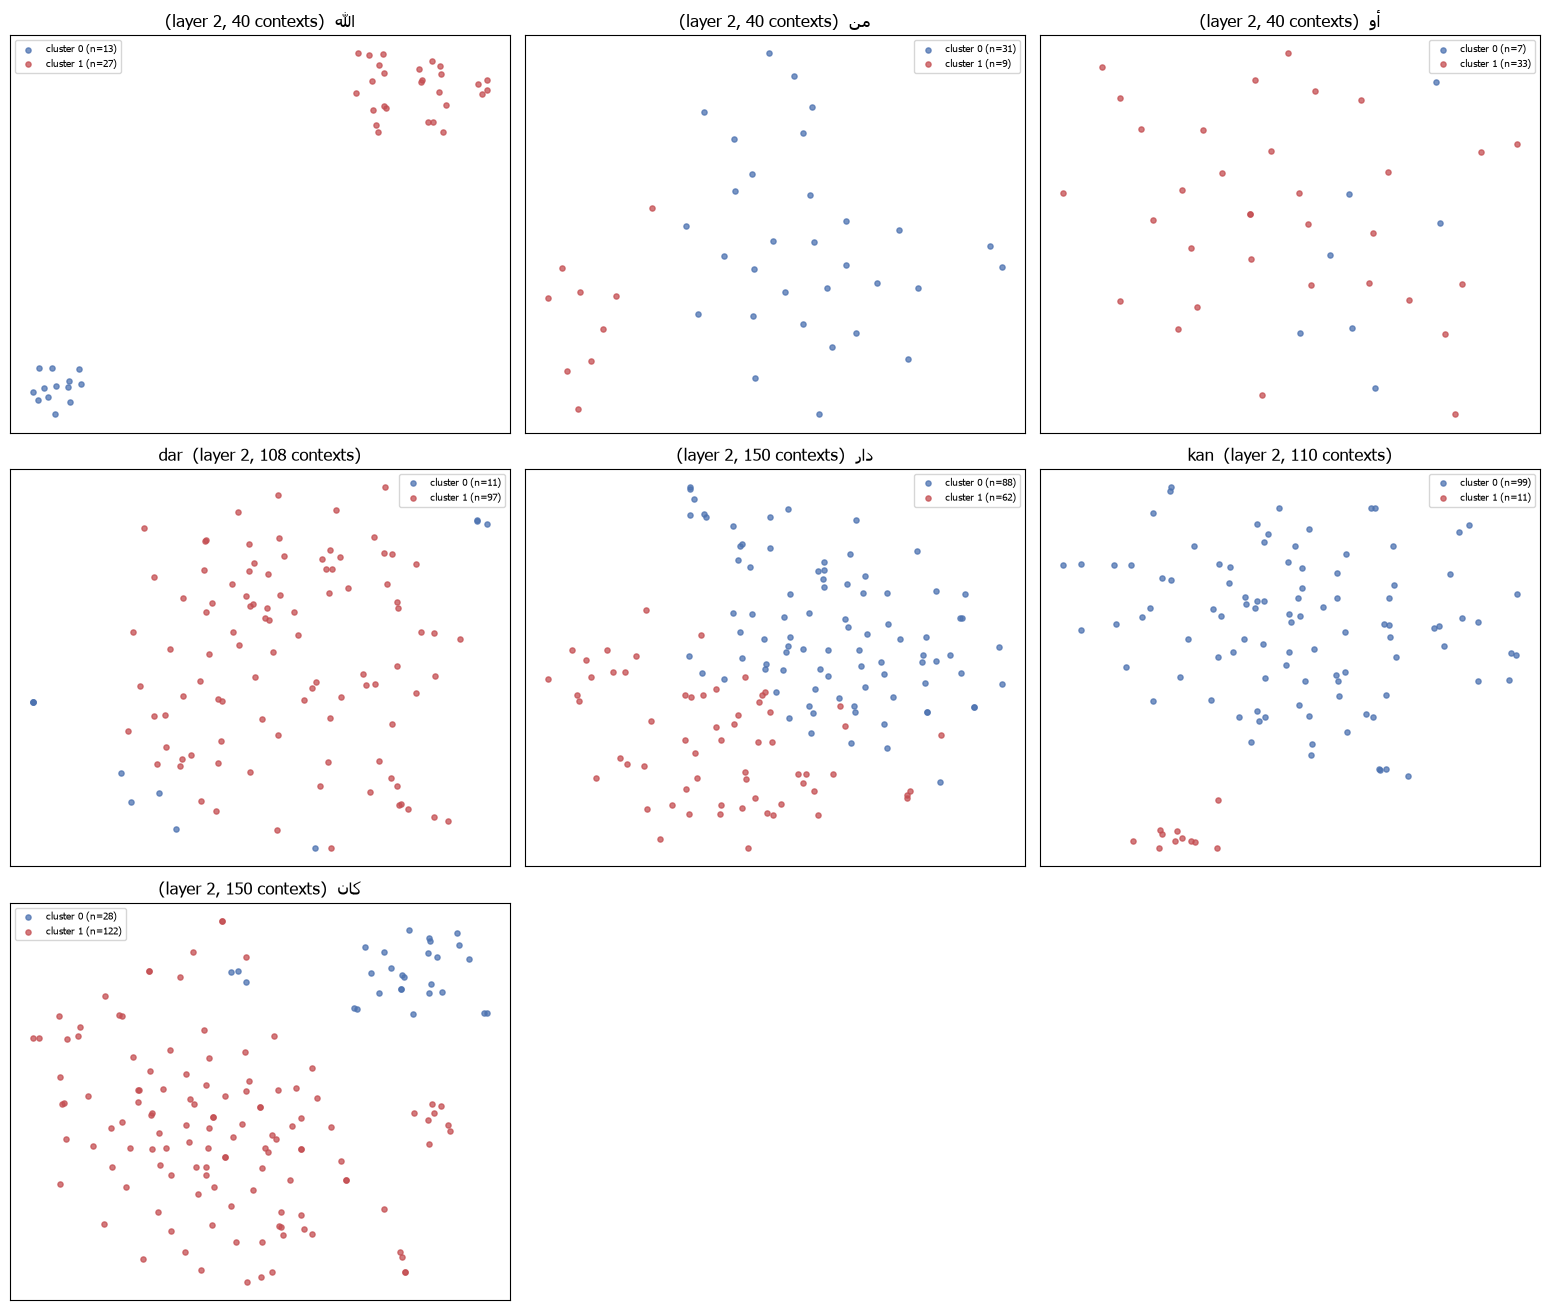

In [8]:
by_change = sorted(sens_vecs, key=lambda w: mean_pairwise_cos(sens_vecs[w][:, 2]))
auto_words = [w for w in by_change if w not in AMB_HAND][:3]
study = []
for w in auto_words + AMB_HAND:
    V, ctx = ctx_vectors(w, 150)
    if V is not None and len(V) >= 20:
        study.append((w, V, ctx))
    else:
        print(f"skipping {w!r}: only {0 if V is None else len(V)} contexts in the sample")

ncol = 3
nrow = (len(study) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 4.4 * nrow), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, (w, V, ctx) in zip(axes.ravel(), study):
    X2 = V[:, 2]
    km = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X2)
    xy = TSNE(n_components=2, random_state=0, perplexity=min(30, max(5, len(X2) // 4)), init="pca").fit_transform(X2)
    ax.axis("on")
    for c, col in ((0, "#4C72B0"), (1, "#C44E52")):
        ax.scatter(xy[km.labels_ == c, 0], xy[km.labels_ == c, 1], s=14, color=col, alpha=0.75, label=f"cluster {c} (n={int((km.labels_ == c).sum())})")
    ax.set_title(f"{render_label(w)}  (layer 2, {len(V)} contexts)"); ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=7)
    print(f"\n=== {w}  (layer-2 self-similarity {mean_pairwise_cos(V[:, 2]):.3f}) ===")
    for c in (0, 1):
        idx = np.where(km.labels_ == c)[0][:3]
        print(f" cluster {c}:")
        for i in idx:
            print("   ", show(*ctx[i]))
plt.tight_layout(); plt.show()

## 2. Nearest neighbors

**(a) Static neighbors, layer by layer.** Each of the 3,000 most frequent words gets a static vector (average over
up to 10 contexts). Neighbors are ranked by cosine over that pool for the same demo words as the GloVe notebook, at
layer 0 (spelling only, so expect look-alike strings, including cross-script neighbors of nothing) and layer 2
(what the words *do* in sentences). The words are looked up in the pool's lowercased form; a demo word outside the pool
is still embedded but is shown only if it can be encoded.

In [9]:
pool_words = [w for w in POOL if w in TOKVEC]
pool_mats = {}
for l in (0, 1, 2):
    M_ = np.stack([TOKVEC[w][l] for w in pool_words])
    pool_mats[l] = M_ / np.clip(np.linalg.norm(M_, axis=1, keepdims=True), 1e-9, None)


def static_neighbors(word: str, layer: int, k: int = 8):
    v = word_static(word)
    if v is None:
        return []
    v = v[layer] / max(np.linalg.norm(v[layer]), 1e-9)
    sims = pool_mats[layer] @ v
    out = []
    for i in np.argsort(-sims):
        if pool_words[i] == word.lower():
            continue
        out.append((pool_words[i], float(sims[i])))
        if len(out) >= k:
            break
    return out


for w in demo_words + arabizi_demo_words:
    n0, n2 = static_neighbors(w, 0), static_neighbors(w, 2)
    print(f"\n{w}:")
    print(f"  {'layer 0 (char-CNN)':<34} | layer 2")
    for (a_, s_a), (b_, s_b) in zip(n0, n2):
        print(f"  {s_a:.3f}  {a_:<26} | {s_b:.3f}  {b_}")


بزاف:
  layer 0 (char-CNN)                 | layer 2
  0.951  بزااف                      | 0.944  بزااف
  0.865  برافو                      | 0.627  برافو
  0.858  بسيف                       | 0.581  شويا
  0.842  باطل                       | 0.557  شوي
  0.840  باسكو                      | 0.541  عادي
  0.818  لبارح                      | 0.524  بسيف
  0.810  كفاه                       | 0.510  بيسك
  0.804  تاعو                       | 0.508  نورمال

خدمة:
  layer 0 (char-CNN)                 | layer 2
  0.942  شخصية                      | 0.872  شخصية
  0.942  جملة                       | 0.812  جملة
  0.928  خمسة                       | 0.795  حياة
  0.927  خطرة                       | 0.785  مشكلة
  0.921  هدرة                       | 0.784  قيمة
  0.919  كلمة                       | 0.783  نهاية
  0.919  منحة                       | 0.772  منطقة
  0.916  نقطة                       | 0.771  غلطة

واش:
  layer 0 (char-CNN)                 | layer 2
  0.962  وش                     

**(b) Contextual neighbors of one occurrence.** For the ambiguous words above, take the first occurrence as the query
and rank the *other occurrences of the same word* by layer-2 cosine. Unlike a static neighbor list this can tell
apart uses of one spelling: the nearest occurrences should share the query's use, the farthest ones should not.

In [10]:
for w, V, ctx in study[-len(AMB_HAND):]:
    X2 = V[:, 2] / np.clip(np.linalg.norm(V[:, 2], axis=1, keepdims=True), 1e-9, None)
    for q in (0, 1):
        sims = X2 @ X2[q]
        order = [i for i in np.argsort(-sims) if i != q]
        print(f"\n=== {w}: query {q}: {show(*ctx[q])}")
        for i in order[:3]:
            print(f"   near {sims[i]:.3f}  {show(*ctx[i])}")
        i = order[-1]
        print(f"   FAR  {sims[i]:.3f}  {show(*ctx[i])}")


=== dar: query 0: ana khdemt m3ahom o makhalsonich big scammers hta boss ta3hom «dar» big scam b milliars de dollars o 9ela3 rah motaba3 dowaliyan
   near 0.938  hh haw kayen sa7bek hadak chiyat eli «dar» fi ghounia hadik ta3 vote
   near 0.938  Darak srira ou galbak kbir wahnin karman «dar» kbira walgalb khal rebika nhabok avonci
   near 0.936  Lmonafa9 ta3 mouha haka ydiro monaf9in nhar jat 3ndhem «dar» hawezha w derk 9odam babaha y3ana9 fiha 😂
   FAR  0.700  «Dar» essad ce nom en arab mais les lettres en français et la traduction de

=== dar: query 1: Lferha ✖ redx «dar» vd ✔ 😂 😂 chkn m3aya
   near 0.925  Enfin wehd «dar» la Remarque grv mtthmlch 🤣
   near 0.903  Ya3rafalhaa «dar» vdo b eng bch yamchi msg mi prQ mdkhalch f tndns
   near 0.899  Voila helet «dar» bla rajel wli maknch fiha lkbiir
   FAR  0.699  «Dar» el hadith a été créé par les tlemceniens monsieur

=== دار: query 0: راني نشوف في دنفيل مع بقرة يأنا «دار» عقلي يأنت درتني تحريشة
   near 0.822  عرفت وسمو الليسي «دار» ما

## 3. Intrinsic evaluation (`evaluate_embeddings.py`)

The same word-similarity (Spearman) and analogy (vector arithmetic, candidates = words in the analogy file)
evaluation as the GloVe notebook, using **static** ELMo vectors (context-average, see above) for each layer, the
plain average of the three layers, and GloVe (words, own coverage) for reference. Static vectors are not what
ELMo is built for, so read this as "does the contextual model still carry word-level meaning", not as its headline
result -- the probes in sections 5-6 are. ELMo embeds every word (the char-CNN has no OOV), so its coverage is
100%, while GloVe skips words outside its 20K vocabulary and is scored on fewer items. As in the GloVe notebook,
overall similarity rho can be negative for a SimLex-style benchmark (antonyms share contexts; cross-script
spellings score high but rarely co-occur).

In [11]:
import warnings
from evaluate_embeddings import evaluate_similarity, evaluate_analogies

best_glove = json.loads((GLOVE_DIR / "models" / "best.json").read_text(encoding="utf-8"))
assert best_glove["mode"] == "words"
E_glove = np.load(GLOVE_DIR / "models" / best_glove["model_file"])["embeddings"]
vocab_glove = json.loads((GLOVE_DIR / "data" / "vocab_words.json").read_text(encoding="utf-8"))
glove_id = {w: i for i, w in enumerate(vocab_glove)}


def glove_vec(word: str):
    i = glove_id.get(word.lower())
    return None if i is None else E_glove[i]


def layer_fn(view):
    def f(word):
        v = word_static(word)
        return None if v is None else view(v)
    return f


variants = {
    "ELMo layer 0 (char-CNN)": layer_fn(lambda v: v[0]),
    "ELMo layer 1": layer_fn(lambda v: v[1]),
    "ELMo layer 2": layer_fn(lambda v: v[2]),
    "ELMo mean of 3 layers": layer_fn(lambda v: v.mean(0)),
    "GloVe words d=64": glove_vec,
}
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, fn in variants.items():
        s, a_ = evaluate_similarity(fn), evaluate_analogies(fn)
        rows.append((name, s["overall_spearman"], s["n_pairs_scored"], s["n_pairs_oov"], a_["overall_accuracy"],
                     a_["overall_n_questions"], {c: r["accuracy"] for c, r in a_["by_category"].items()}))

print(f"{'variant':<26} {'sim rho':>8} {'scored/OOV':>11} {'analogy acc':>12} {'questions':>10}")
for name, rho, n_ok, n_oov, acc, n_q, _ in rows:
    print(f"{name:<26} {rho:>8.4f} {n_ok:>5}/{n_oov:<5} {acc:>12.4f} {n_q:>10}")
print("\nAnalogy accuracy by category:")
cats = list(rows[0][6])
print(f"{'category':<24}" + "".join(f"{r[0][-14:]:>16}" for r in rows))
for c in cats:
    print(f"{c:<24}" + "".join(f"{r[6][c]:>16.3f}" for r in rows))
RESULTS["intrinsic"] = {r[0]: {"similarity_rho": r[1], "pairs_scored": r[2], "pairs_oov": r[3], "analogy_acc": r[4], "questions": r[5]} for r in rows}

variant                     sim rho  scored/OOV  analogy acc  questions
ELMo layer 0 (char-CNN)     -0.5786   215/0           0.0981       4290
ELMo layer 1                -0.5330   215/0           0.0956       4290
ELMo layer 2                -0.5006   215/0           0.1366       4290
ELMo mean of 3 layers       -0.5744   215/0           0.1042       4290
GloVe words d=64            -0.4512   136/79          0.2986       3309

Analogy accuracy by category:
category                  r 0 (char-CNN)    ELMo layer 1    ELMo layer 2  an of 3 layers  oVe words d=64
gender                             0.276           0.148           0.318           0.278           0.705
singular_plural                    0.160           0.176           0.198           0.185           0.444
script_transliteration             0.016           0.050           0.054           0.017           0.088


## 4. Word clustering (unsupervised K-Means)

The hand-picked sentiment words (k=2) and entity-type words (k=4) from the GloVe notebook, embedded with their static
ELMo vector per layer; K-Means is fit without labels and scored with the Adjusted Rand Index (0 = chance, 1 = perfect).
The words are those GloVe can also embed, so every column scores the identical word set. The lists are 16-32 words:
treat differences of a few hundredths as noise.

In [12]:
def ari_for(embed_fn, groups, k, common):
    keep = set(common)
    vecs, labels = [], []
    for label, ws in groups.items():
        for w in ws:
            if w in keep:
                vecs.append(embed_fn(w)); labels.append(label)
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(np.stack(vecs))
    return adjusted_rand_score(labels, km.labels_), len(vecs)


cols = {"GloVe": glove_vec, "ELMo L0": layer_fn(lambda v: v[0]), "ELMo L1": layer_fn(lambda v: v[1]),
        "ELMo L2": layer_fn(lambda v: v[2]), "ELMo mean": layer_fn(lambda v: v.mean(0))}
print(f"{'task':<20} {'common':>8}" + "".join(f"{c:>11}" for c in cols))
RESULTS["clustering_ari"] = {}
for task, (groups, k) in TASKS.items():
    common = [w for ws in groups.values() for w in ws if glove_vec(w) is not None]
    aris = {c: ari_for(f, groups, k, common)[0] for c, f in cols.items()}
    total = sum(len(ws) for ws in groups.values())
    print(f"{task:<20} {len(common):>4}/{total:<3}" + "".join(f"{aris[c]:>11.3f}" for c in cols))
    RESULTS["clustering_ari"][task] = aris

task                   common      GloVe    ELMo L0    ELMo L1    ELMo L2  ELMo mean


sentiment (k=2)        17/20       0.558     -0.036     -0.036     -0.036     -0.036


entity type (k=4)      32/32       0.828      0.106      0.313      0.668      0.325


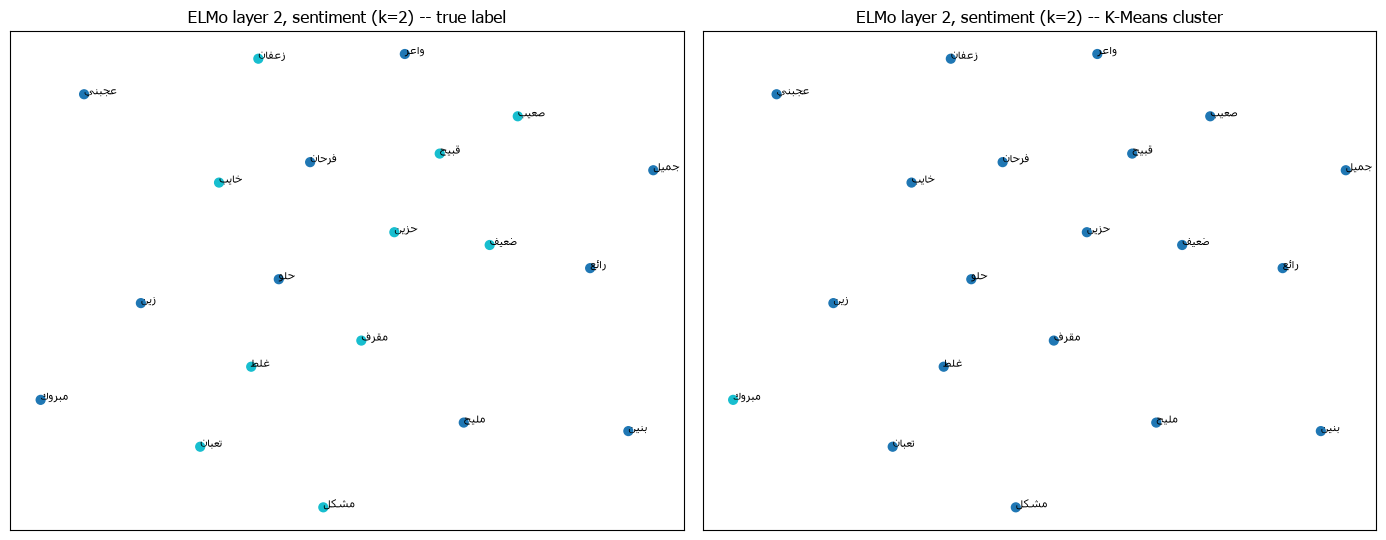

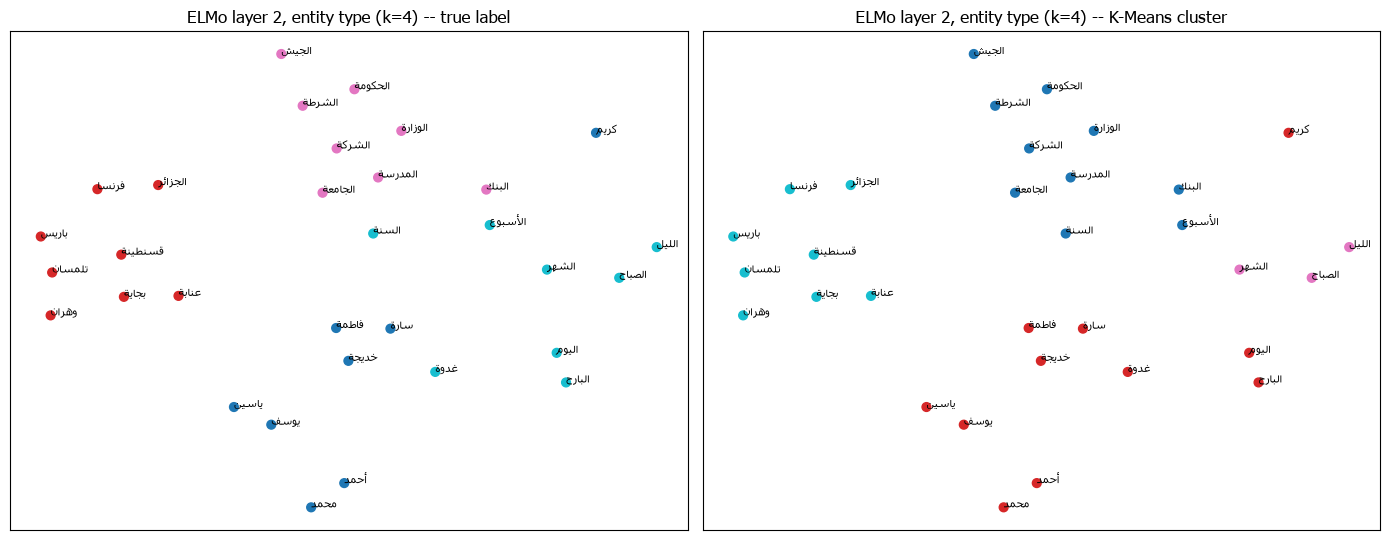

In [13]:
def cluster_plot(groups, k, embed_fn, title):
    words, labels, vecs = [], [], []
    for label, ws in groups.items():
        for w in ws:
            v = embed_fn(w)
            if v is not None:
                words.append(w); labels.append(label); vecs.append(v)
    X = np.stack(vecs)
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    xy = TSNE(n_components=2, random_state=42, perplexity=min(10, len(X) - 1), init="pca").fit_transform(X)
    names_ = list(groups)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, colours, ttl in ((axes[0], [names_.index(l) for l in labels], "true label"), (axes[1], km.labels_, "K-Means cluster")):
        ax.scatter(xy[:, 0], xy[:, 1], c=colours, cmap="tab10", s=40)
        for (x_, y_), w in zip(xy, words):
            ax.annotate(render_label(w), (x_, y_), fontsize=8)
        ax.set_title(f"{title} -- {ttl}"); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()


for task, (groups, k) in TASKS.items():
    cluster_plot(groups, k, layer_fn(lambda v: v[2]), f"ELMo layer 2, {task}")

## 5. Layer-wise POS probe (NArabizi UPOS)

The paper's central analysis: freeze the biLM, train only a linear softmax layer on top of one layer's vectors, and
compare accuracies -- differences show what each layer already encodes (the paper finds syntax lower, semantics
higher). Feature sets:

- **ELMo layer 0** -- char-CNN only (spelling, no context; 256-d, the forward/backward copies are identical);
  **layer 1**, **layer 2** -- concatenated forward|backward states; **layer 2 fwd only / bwd only** -- to show
  that both directions carry information; **scalar mix** -- learned softmax weights over the 3 layers + gamma.
- **Random-init biLM** -- same architecture, untrained: how much of the result is just the architecture and
  the char-CNN feature extractor?
- **GloVe** -- static word vectors (words model, 64-d; a word outside its vocabulary gets the zero vector).

NArabizi's words are already tokenized, so each sentence's word forms are fed to the biLM as-is. Train 998 sentences,
dev 137, test 144 -- small, hence 3 seeds (only the probe's initialisation and batch order vary; the features are
fixed) and mean +- std. Test accuracy is taken at the epoch with the best dev accuracy.

In [14]:
from probe_pos import read_conllu, train_probe

POS_DIR = ROOT / "Benchmarks" / "NArabizi-main" / "data" / "Narabizi" / "pos"
pos_splits = {s: read_conllu(POS_DIR / f"{s}_NArabizi.conllu") for s in ("train", "dev", "test")}
tagset = sorted({t for v in pos_splits.values() for _, ts in v for t in ts})
tid = {t: i for i, t in enumerate(tagset)}
y_pos = {s: torch.tensor([tid[t] for _, ts in v for t in ts]) for s, v in pos_splits.items()}
print({s: len(v) for s, v in y_pos.items()}, "tokens;", len(tagset), "tags:", tagset)


def standardize(train, *others):
    mu = train.mean(0, keepdim=True)
    sd = train.std(0, keepdim=True).clamp_min(1e-6)
    return [(t - mu) / sd for t in (train,) + others]


def run_probe(F, y, n_classes, mix=False, seeds=(0, 1, 2), epochs=100):
    tr, dv, te = standardize(F["train"], F["dev"], F["test"])
    outs = []
    for sd in seeds:
        torch.manual_seed(sd)
        r = train_probe(tr, y["train"], dv, y["dev"], te, y["test"], n_classes, mix=mix, epochs=epochs)
        r["macro_f1"] = f1_score(y["test"].numpy(), r["test_pred"], average="macro")
        outs.append(r)
    acc, f1 = [o["test"] for o in outs], [o["macro_f1"] for o in outs]
    return {"acc": float(np.mean(acc)), "acc_std": float(np.std(acc)), "f1": float(np.mean(f1)),
            "mix_weights": np.mean([o["mix_weights"] for o in outs], 0).tolist() if mix else None}


def pos_features(e):
    return {s: torch.cat([r.transpose(0, 1) for r in e.encode([w for w, _ in v])]) for s, v in pos_splits.items()}


t0 = time.time()
X_pos, X_pos_rand = pos_features(enc), pos_features(enc_rand)
glove_oov = [0, 0]


def glove_pos_features():
    out = {}
    for s, v in pos_splits.items():
        rows_ = []
        for words, _ in v:
            for w in words:
                g = glove_vec(w)
                glove_oov[1] += 1
                if g is None:
                    glove_oov[0] += 1
                rows_.append(np.zeros(E_glove.shape[1], dtype=np.float32) if g is None else g)
        out[s] = torch.from_numpy(np.stack(rows_))
    return out


X_pos_glove = glove_pos_features()
print(f"features built in {time.time() - t0:.0f}s; GloVe covers {1 - glove_oov[0] / glove_oov[1]:.1%} of POS tokens")

POS_SETS = {
    "ELMo layer 0 (char-CNN only)": (X_pos, lambda X: X[:, 0, :D2], False),
    "ELMo layer 1": (X_pos, lambda X: X[:, 1], False),
    "ELMo layer 2 (fwd|bwd)": (X_pos, lambda X: X[:, 2], False),
    "ELMo layer 2 forward only": (X_pos, lambda X: X[:, 2, :D2], False),
    "ELMo layer 2 backward only": (X_pos, lambda X: X[:, 2, D2:], False),
    "ELMo scalar mix": (X_pos, lambda X: X, True),
    "random-init biLM layer 2": (X_pos_rand, lambda X: X[:, 2], False),
    "random-init biLM scalar mix": (X_pos_rand, lambda X: X, True),
    "GloVe words d=64": (X_pos_glove, lambda X: X, False),
}
pos_res = {}
print(f"{'features':<32} {'test acc':>9} {'+-':>7} {'macro-F1':>9}")
for name, (X, view, mix) in POS_SETS.items():
    pos_res[name] = run_probe({s: view(X[s]) for s in X}, y_pos, len(tagset), mix=mix)
    r = pos_res[name]
    print(f"{name:<32} {r['acc']:>9.4f} {r['acc_std']:>7.4f} {r['f1']:>9.4f}" + (f"   mix weights {np.round(r['mix_weights'], 3).tolist()}" if mix else ""))
maj = np.bincount(y_pos["test"].numpy()).max() / len(y_pos["test"])
print(f"majority-tag baseline: {maj:.4f}")
RESULTS["pos_probe"] = pos_res
RESULTS["pos_majority"] = float(maj)

{'train': 14869, 'dev': 2157, 'test': 2117} tokens; 22 tags: ['ADJ', 'ADP', 'ADP+ADJ', 'ADP+NOUN', 'ADP+PRON', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PART+VERB', 'PRO', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'VERB', 'VERB+PRON', 'X']


features built in 16s; GloVe covers 55.3% of POS tokens
features                          test acc      +-  macro-F1


ELMo layer 0 (char-CNN only)        0.6942  0.0030    0.6346


ELMo layer 1                        0.7207  0.0035    0.6224


ELMo layer 2 (fwd|bwd)              0.7274  0.0004    0.6272


...

ELMo layer 2 backward only          0.6931  0.0016    0.5917


ELMo scalar mix                     0.7405  0.0012    0.6685   mix weights [0.328, 0.175, 0.497]


random-init biLM layer 2            0.5610  0.0036    0.4800


random-init biLM scalar mix         0.6430  0.0012    0.6065   mix weights [0.627, 0.191, 0.183]


GloVe words d=64                    0.5385  0.0017    0.4768
majority-tag baseline: 0.2107


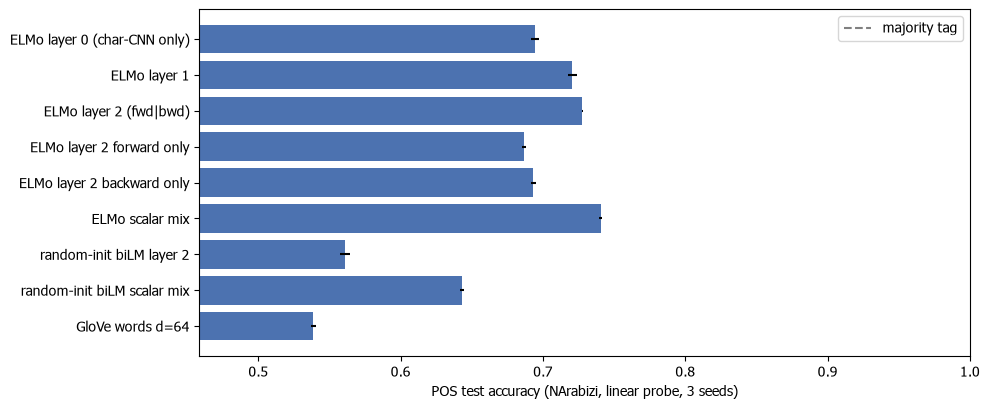

In [15]:
names_ = list(pos_res)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(range(len(names_)), [pos_res[n]["acc"] for n in names_], xerr=[pos_res[n]["acc_std"] for n in names_], color="#4C72B0")
ax.axvline(maj, color="gray", ls="--", label="majority tag")
ax.set_yticks(range(len(names_))); ax.set_yticklabels(names_); ax.invert_yaxis()
ax.set_xlabel("POS test accuracy (NArabizi, linear probe, 3 seeds)"); ax.legend()
lo = min(pos_res[n]["acc"] for n in names_)
ax.set_xlim(max(0, lo - 0.08), 1.0)
plt.tight_layout(); plt.show()

### Sample efficiency

The paper reports that ELMo needs far less labelled data. Same probe (scalar mix for ELMo, linear on GloVe),
trained on a growing fraction of the training *sentences* (dev/test unchanged), 2 seeds each.

train fraction                       10%     25%     50%    100%
ELMo scalar mix                    0.665   0.697   0.707   0.740
random-init biLM scalar mix        0.537   0.573   0.610   0.642
GloVe words d=64                   0.500   0.517   0.531   0.539


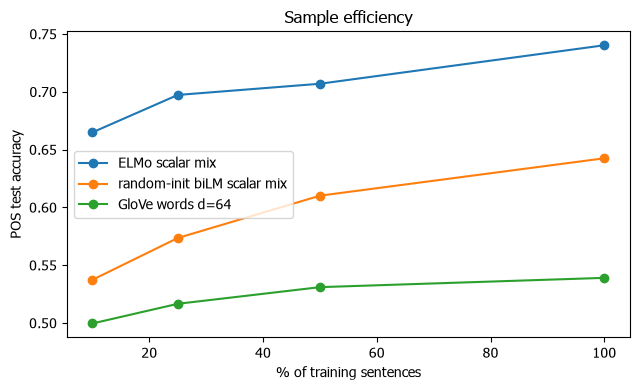

In [16]:
def subset(F, y, frac, seed=0):
    n = len(pos_splits["train"])
    keep = set(np.random.default_rng(seed).permutation(n)[: max(1, int(n * frac))].tolist())
    mask = torch.zeros(len(y["train"]), dtype=torch.bool)
    pos = 0
    for i, (w, _) in enumerate(pos_splits["train"]):
        if i in keep:
            mask[pos:pos + len(w)] = True
        pos += len(w)
    F2 = dict(F); F2["train"] = F["train"][mask]
    y2 = dict(y); y2["train"] = y["train"][mask]
    return F2, y2


fracs = (0.1, 0.25, 0.5, 1.0)
eff = {"ELMo scalar mix": {}, "random-init biLM scalar mix": {}, "GloVe words d=64": {}}
for name in eff:
    X, view, mix = POS_SETS[name]
    for f in fracs:
        F2, y2 = subset({s: view(X[s]) for s in X}, y_pos, f)
        eff[name][f] = run_probe(F2, y2, len(tagset), mix=mix, seeds=(0, 1))["acc"]
print(f"{'train fraction':<32}" + "".join(f"{int(f * 100):>7d}%" for f in fracs))
for name, d in eff.items():
    print(f"{name:<32}" + "".join(f"{d[f]:>8.3f}" for f in fracs))
fig, ax = plt.subplots(figsize=(6.5, 4))
for name, d in eff.items():
    ax.plot([f * 100 for f in fracs], [d[f] for f in fracs], "o-", label=name)
ax.set_xlabel("% of training sentences"); ax.set_ylabel("POS test accuracy"); ax.legend(); ax.set_title("Sample efficiency")
plt.tight_layout(); plt.show()
RESULTS["pos_sample_efficiency"] = {n: {str(f): a_ for f, a_ in d.items()} for n, d in eff.items()}

## 6. Frozen-feature sentence classification

Each sentence is represented by the **mean over its words** of the chosen layer (truncated to 64 words), then a
linear classifier is trained with the same probe as above (biLM frozen). Two tasks:

- **NArabizi sentiment** (`NArabizi_sent/`): 997 / 137 / 144 sentences -- tiny and imbalanced, so accuracy alone is
  misleading; macro-F1 is reported next to the majority-class accuracy, and differences of a few points are noise.
- **Dialect ID** (`Dialect_Identification/data`): 6 classes (msa, darija, arabize, french, english, code_switch);
  a random 20,000-comment subsample of the 48K training set (2,000 of them held out as dev) and the **full**
  12,000-comment test set. This one is large enough to be the more reliable comparison, but it is mostly a
  script/language task -- expect a spelling-only baseline (layer 0) to already do well.

Baselines: GloVe mean vector (64-d; words outside its vocabulary skipped) and the random-init biLM.

In [17]:
def read_jsonl(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return [json.loads(l) for l in f if l.strip()]


def glove_mean(rows):
    out = np.zeros((len(rows), E_glove.shape[1]), dtype=np.float32)
    for i, r in enumerate(rows):
        vs = [g for g in (glove_vec(t) for t in TOKEN_RE.findall(r["text"])) if g is not None]
        if vs:
            out[i] = np.mean(vs, axis=0)
    return torch.from_numpy(out)


def sentence_task(name, splits):
    labels = sorted({r["label"] for v in splits.values() for r in v})
    lid = {l: i for i, l in enumerate(labels)}
    y = {s: torch.tensor([lid[r["label"]] for r in v]) for s, v in splits.items()}
    toks = {s: [TOKEN_RE.findall(r["text"]) for r in v] for s, v in splits.items()}
    t0 = time.time()
    X = {s: enc.encode_mean(toks[s]) for s in splits}
    Xr = {s: enc_rand.encode_mean(toks[s]) for s in splits}
    Xg = {s: glove_mean(splits[s]) for s in splits}
    print(f"{name}: {len(labels)} classes {labels}; features in {time.time() - t0:.0f}s")
    maj_acc = np.bincount(y["test"].numpy()).max() / len(y["test"])
    sets = {
        "ELMo layer 0 (char-CNN only)": (X, lambda A: A[:, 0, :D2], False),
        "ELMo layer 1": (X, lambda A: A[:, 1], False),
        "ELMo layer 2": (X, lambda A: A[:, 2], False),
        "ELMo scalar mix": (X, lambda A: A, True),
        "random-init biLM scalar mix": (Xr, lambda A: A, True),
        "GloVe mean vector": (Xg, lambda A: A, False),
    }
    epochs = 100 if len(y["train"]) < 2000 else 40
    res = {}
    print(f"{'features':<32} {'test acc':>9} {'+-':>7} {'macro-F1':>9}   (majority-class acc {maj_acc:.3f})")
    for k, (XX, view, mix) in sets.items():
        res[k] = run_probe({s: view(XX[s]) for s in XX}, y, len(labels), mix=mix, epochs=epochs)
        r = res[k]
        print(f"{k:<32} {r['acc']:>9.4f} {r['acc_std']:>7.4f} {r['f1']:>9.4f}" + (f"   mix weights {np.round(r['mix_weights'], 3).tolist()}" if mix else ""))
    res["majority_acc"] = float(maj_acc)
    return res


sent_rows = {s: read_jsonl(ROOT / "NArabizi_sent" / "data" / f"{s}.jsonl") for s in ("train", "dev", "test")}
sent_res = sentence_task("NArabizi sentiment", sent_rows)
RESULTS["sentiment"] = sent_res

NArabizi sentiment: 4 classes ['MIX', 'NEG', 'NEU', 'POS']; features in 4s
features                          test acc      +-  macro-F1   (majority-class acc 0.410)


ELMo layer 0 (char-CNN only)        0.4745  0.0033    0.4090


ELMo layer 1                        0.5255  0.0065    0.4872


ELMo layer 2                        0.5347  0.0316    0.4915


ELMo scalar mix                     0.5162  0.0199    0.4701   mix weights [0.319, 0.329, 0.353]


random-init biLM scalar mix         0.4884  0.0312    0.4599   mix weights [0.339, 0.331, 0.33]


GloVe mean vector                   0.5394  0.0118    0.4470


In [18]:
DI = ROOT / "Dialect_Identification" / "data"
di_train_all = read_jsonl(DI / "train.jsonl")
perm = np.random.default_rng(0).permutation(len(di_train_all))[:20000]
di_rows = {"dev": [di_train_all[i] for i in perm[:2000]],
           "train": [di_train_all[i] for i in perm[2000:]],
           "test": read_jsonl(DI / "test.jsonl")}
print({s: len(v) for s, v in di_rows.items()})
dialect_res = sentence_task("Dialect ID", di_rows)
RESULTS["dialect_id"] = dialect_res

{'dev': 2000, 'train': 18000, 'test': 12000}


Dialect ID: 6 classes ['arabize', 'code_switch', 'darija', 'english', 'french', 'msa']; features in 47s
features                          test acc      +-  macro-F1   (majority-class acc 0.167)


ELMo layer 0 (char-CNN only)        0.8548  0.0006    0.8525


ELMo layer 1                        0.9204  0.0004    0.9208


ELMo layer 2                        0.9201  0.0004    0.9203


ELMo scalar mix                     0.9229  0.0013    0.9231   mix weights [0.172, 0.439, 0.389]


random-init biLM scalar mix         0.8252  0.0020    0.8231   mix weights [0.428, 0.295, 0.277]


GloVe mean vector                   0.8198  0.0010    0.8150


## 7. Learned layer weights and summary

The softmax-normalised scalar-mix weights the probes settled on (mean over 3 seeds): where a task puts its weight
shows which layer it finds most useful -- in the paper, syntax-heavy tasks lean on the lower layers and
semantics-heavy tasks on the upper ones. With one frozen biLM and a linear head, the weights are a rough
indicator, not a proof.

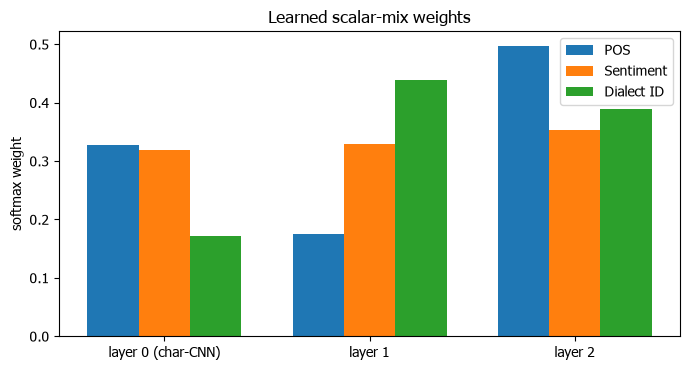

features                           POS acc  sentiment F1  dialect F1
ELMo layer 0 (char-CNN only)        0.6942        0.4090      0.8525
ELMo layer 1                        0.7207        0.4872      0.9208
ELMo layer 2                        0.7274        0.4915      0.9203
ELMo scalar mix                     0.7405        0.4701      0.9231
random-init biLM scalar mix         0.6430        0.4599      0.8231
GloVe                               0.5385        0.4470      0.8150
saved C:\Users\ASUS\Desktop\summer 2026\Darija\Embeddings\elmo\models\elmo_eval_results.json


In [19]:
mixw = {"POS": pos_res["ELMo scalar mix"]["mix_weights"],
        "Sentiment": sent_res["ELMo scalar mix"]["mix_weights"],
        "Dialect ID": dialect_res["ELMo scalar mix"]["mix_weights"]}
fig, ax = plt.subplots(figsize=(7, 3.8))
w_ = 0.25
for j, (task, w) in enumerate(mixw.items()):
    ax.bar(np.arange(3) + (j - 1) * w_, w, w_, label=task)
ax.set_xticks(range(3)); ax.set_xticklabels(["layer 0 (char-CNN)", "layer 1", "layer 2"])
ax.set_ylabel("softmax weight"); ax.set_title("Learned scalar-mix weights"); ax.legend()
plt.tight_layout(); plt.show()
RESULTS["mix_weights"] = mixw

print(f"{'features':<32} {'POS acc':>9} {'sentiment F1':>13} {'dialect F1':>11}")
for name, pos_name in (("ELMo layer 0 (char-CNN only)", "ELMo layer 0 (char-CNN only)"), ("ELMo layer 1", "ELMo layer 1"),
                       ("ELMo layer 2", "ELMo layer 2 (fwd|bwd)"), ("ELMo scalar mix", "ELMo scalar mix"),
                       ("random-init biLM scalar mix", "random-init biLM scalar mix"), ("GloVe", None)):
    p = pos_res[pos_name]["acc"] if pos_name else pos_res["GloVe words d=64"]["acc"]
    s_ = sent_res["GloVe mean vector" if name == "GloVe" else name]["f1"]
    d_ = dialect_res["GloVe mean vector" if name == "GloVe" else name]["f1"]
    print(f"{name:<32} {p:>9.4f} {s_:>13.4f} {d_:>11.4f}")

out = MODELS_DIR / "elmo_eval_results.json"
out.write_text(json.dumps(RESULTS, indent=2, default=float), encoding="utf-8")
print("saved", out)

## Caveats to keep in mind when reading the numbers

- **Small evaluation sets.** NArabizi POS (144 test sentences) and sentiment (144) are tiny; the standard deviations
  above only cover probe initialisation, not the choice of test set. The dialect-ID comparison is the more reliable one.
- **Dialect ID measures script/language more than dialect semantics**, so a spelling-only layer 0 can already
  score high there.
- **Static vectors (sections 3-4) undersell ELMo**, and depend on the sampled contexts (the 300 random blocks; the
  sample is fixed by its seed, but a different seed would move the numbers slightly).
- **Contexts overlap the biLM's training text**; that does not affect the probes, which use separate labelled sets.
- **The clusters in section 1 are not gold senses.** They are a prompt to read the printed sentences.
- **Compare like with like.** GloVe is 64-d and static; ELMo layers are 512-d (layer 0: 256-d) and contextual;
  the probes are linear on frozen features for both, but dimensionality alone can move linear-probe accuracy.
- **Perplexity with `<unk>`** is dominated by the 19% `<unk>` class; use the "excluding `<unk>`" curve.